<a href="https://colab.research.google.com/github/ruyoliv/DataCom/blob/main/fdm_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📡 FDM — Multiplexação por Divisão de Frequência

**Ideia central:** 3 usuários compartilham o mesmo cabo (meio de transmissão) simultaneamente — cada um em sua própria faixa de frequência.

| Célula | Conteúdo |
|--------|----------|
| 2 | Configuração: eixo de tempo, usuários, funções auxiliares |
| 3 | Transmissor: modular e somar no sinal FDM |
| 4 | Diagrama do canal: diagrama de blocos + plano de frequências |
| 5 | Receptor: PBF → demodulaçao → PBX → recuperar |
| 6 | Explorador interativo de filtros |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = 'white'

# ── Eixo de tempo ─────────────────────────────────────────────
FS = 10_000          # taxa de amostragem (Hz)
T  = 0.04            # duração (s)
t  = np.linspace(0, T, int(FS * T), endpoint=False)

# ── Três usuários ─────────────────────────────────────────────
# Cada usuário tem: frequência da mensagem, frequência da portadora e cor
usuarios = {
    'Usuário 1': dict(fm=200,  fc=1000, cor='#1f77b4'),   # azul
    'Usuário 2': dict(fm=300,  fc=2500, cor='#d62728'),   # vermelho
    'Usuário 3': dict(fm=450,  fc=4000, cor='#2ca02c'),   # verde
}

# ── Funções auxiliares ────────────────────────────────────────
def senoide(freq):
    """Gera uma senoide pura na frequência dada."""
    return np.sin(2 * np.pi * freq * t)

def pbf(sinal, fc, bw, ordem=4):
    """Filtro Passa-Baixa centrado em fc com largura de banda bw."""
    lo = max((fc - bw/2) / (FS/2), 0.001)
    hi = min((fc + bw/2) / (FS/2), 0.999)
    b, a = butter(ordem, [lo, hi], btype='band')
    return filtfilt(b, a, sinal)

def pbx(sinal, corte, ordem=6):
    """Filtro Passa-Baixa com frequência de corte dada."""
    b, a = butter(ordem, corte / (FS/2), btype='low')
    return filtfilt(b, a, sinal)

def espectro(sinal):
    """Espectro de magnitude unilateral via FFT."""
    n   = len(sinal)
    mag = np.abs(np.fft.rfft(sinal)) / n
    mag[1:-1] *= 2
    frq = np.fft.rfftfreq(n, 1 / FS)
    return frq, mag

def estilo(ax):
    """Aplica estilo limpo aos eixos."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, color='#f0f0f0')
    ax.set_axisbelow(True)

print('Configuração concluída.')
for nome, p in usuarios.items():
    print(f"  {nome}: mensagem {p['fm']} Hz  →  portadora {p['fc']} Hz")


Configuração concluída.
  Usuário 1: mensagem 200 Hz  →  portadora 1000 Hz
  Usuário 2: mensagem 300 Hz  →  portadora 2500 Hz
  Usuário 3: mensagem 450 Hz  →  portadora 4000 Hz


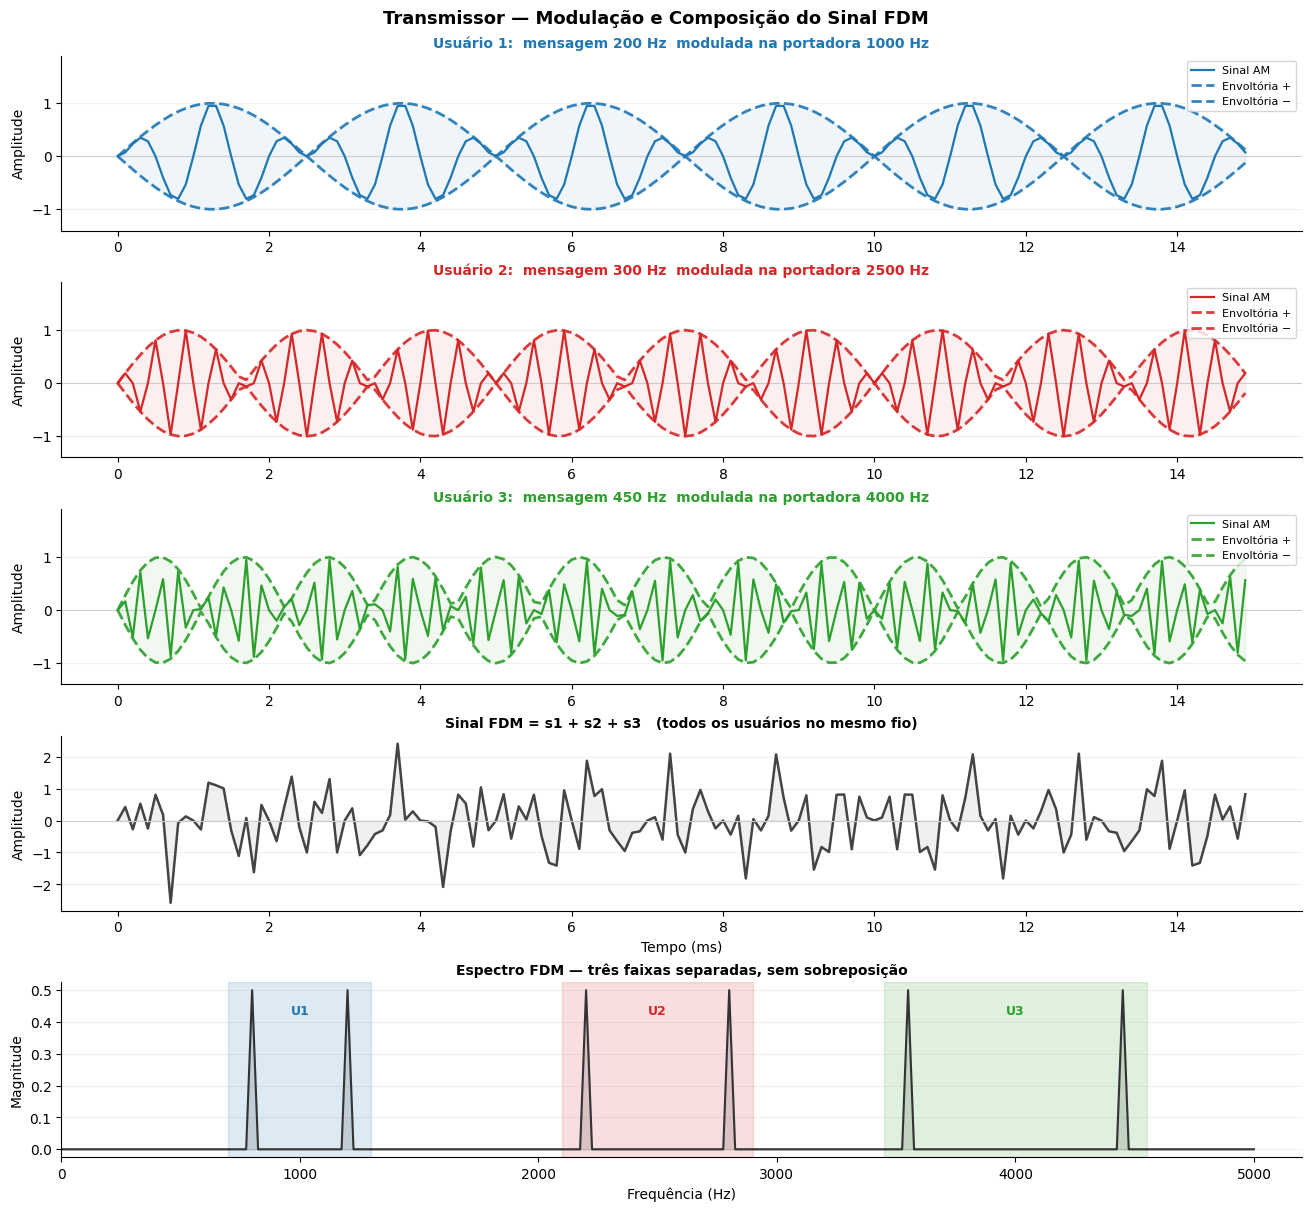

In [2]:
# ── Geração dos sinais ────────────────────────────────────────
# Modulação DSB-SC: s_i(t) = m_i(t) * cos(2*pi*fc_i*t)
# Sem componente de portadora — demodulação limpa e simples
mensagens  = {nome: senoide(p['fm']) for nome, p in usuarios.items()}
modulados  = {nome: mensagens[nome] * senoide(p['fc']) for nome, p in usuarios.items()}
fdm        = sum(modulados.values())   # todos os usuários no mesmo fio

janela = t <= 0.015   # exibir os primeiros 15 ms

fig, eixos = plt.subplots(5, 1, figsize=(13, 12), constrained_layout=True)
fig.suptitle('Transmissor — Modulação e Composição do Sinal FDM',
             fontsize=13, fontweight='bold')

# Linhas 0-2: cada canal modulado individualmente
for ax, (nome, p) in zip(eixos[:3], usuarios.items()):
    c  = p['cor']
    fm = p['fm']
    s  = modulados[nome]
    m  = mensagens[nome]

    # Sinal modulado
    ax.plot(t[janela]*1000, s[janela], color=c, lw=1.6, label='Sinal AM', zorder=3)

    # Envoltória positiva e negativa
    # Para DSB-SC, a envoltória é |m(t)| — usamos ±m(t) para mostrar a forma
    env = np.abs(m)
    ax.plot(t[janela]*1000,  env[janela], color=c, lw=2, ls='--',
            alpha=0.9, label='Envoltória +', zorder=4)
    ax.plot(t[janela]*1000, -env[janela], color=c, lw=2, ls='--',
            alpha=0.9, label='Envoltória −', zorder=4)
    ax.fill_between(t[janela]*1000,  env[janela], -env[janela],
                    alpha=0.07, color=c, zorder=2)

    ax.axhline(0, color='#ccc', lw=0.8)
    ax.set_ylim(-1.4, 1.9)
    ax.set_ylabel('Amplitude')
    ax.set_title(
        f"{nome}:  mensagem {fm} Hz  modulada na portadora {p['fc']} Hz",
        color=c, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    estilo(ax)

# Linha 3: sinal FDM composto
eixos[3].plot(t[janela]*1000, fdm[janela], color='#444', lw=1.8)
eixos[3].fill_between(t[janela]*1000, fdm[janela], alpha=0.08, color='#444')
eixos[3].axhline(0, color='#ccc', lw=0.8)
eixos[3].set_ylabel('Amplitude')
eixos[3].set_xlabel('Tempo (ms)')
eixos[3].set_title(
    'Sinal FDM = s1 + s2 + s3   (todos os usuários no mesmo fio)',
    fontweight='bold', fontsize=10)
estilo(eixos[3])

# Linha 4: espectro do FDM
frq, mag = espectro(fdm)
eixos[4].fill_between(frq, mag, alpha=0.18, color='#444')
eixos[4].plot(frq, mag, color='#333', lw=1.5)
for nome, p in usuarios.items():
    fc, fm, c = p['fc'], p['fm'], p['cor']
    eixos[4].axvspan(fc - fm - 100, fc + fm + 100, alpha=0.15, color=c)
    eixos[4].text(fc, mag.max()*0.85,
                  nome.replace('Usuário ', 'U'),
                  ha='center', fontsize=9, fontweight='bold', color=c)
eixos[4].set_xlim(0, 5200)
eixos[4].set_xlabel('Frequência (Hz)')
eixos[4].set_ylabel('Magnitude')
eixos[4].set_title(
    'Espectro FDM — três faixas separadas, sem sobreposição',
    fontweight='bold', fontsize=10)
estilo(eixos[4])

plt.savefig('fdm_transmissor.png', dpi=130, bbox_inches='tight')
plt.show()


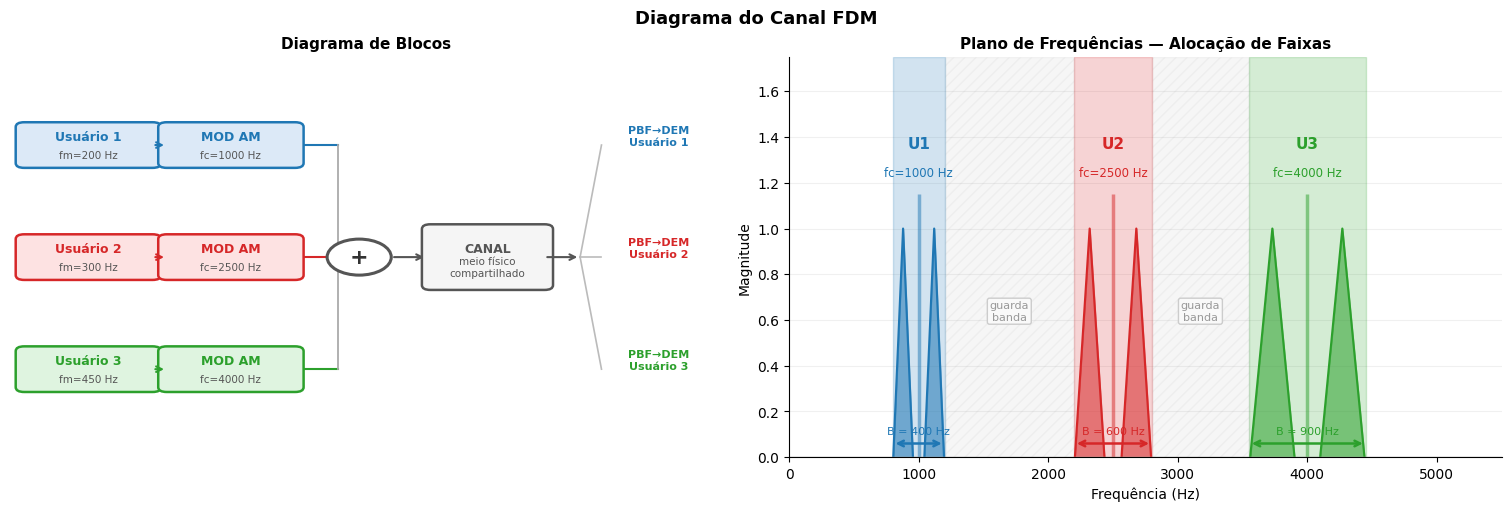

In [3]:
fig, eixos = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
fig.suptitle('Diagrama do Canal FDM', fontsize=13, fontweight='bold')

# ── Esquerda: diagrama de blocos ──────────────────────────────
ax = eixos[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Diagrama de Blocos', fontweight='bold', fontsize=11)

Y_pos  = {'Usuário 1': 7.8, 'Usuário 2': 5.0, 'Usuário 3': 2.2}
fundos = {'Usuário 1': '#dce9f7', 'Usuário 2': '#fde2e2', 'Usuário 3': '#dff4e0'}

def caixa(ax, x, y, w, h, t1, t2, bc, fc):
    r = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                 boxstyle='round,pad=0.12',
                                 ec=bc, fc=fc, lw=1.8, zorder=3)
    ax.add_patch(r)
    ax.text(x, y+0.2,  t1, ha='center', va='center', fontsize=9,
            fontweight='bold', color=bc, zorder=4)
    ax.text(x, y-0.25, t2, ha='center', va='center', fontsize=7.5,
            color='#555', zorder=4)

def seta(ax, x1, y1, x2, y2, c='#777'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=c, lw=1.5))

for nome, p in usuarios.items():
    y = Y_pos[nome]; c = p['cor']; cf = fundos[nome]
    caixa(ax, 1.1, y, 1.8, 0.9, nome,     f"fm={p['fm']} Hz", c, cf)
    caixa(ax, 3.1, y, 1.8, 0.9, 'MOD AM', f"fc={p['fc']} Hz", c, cf)
    seta(ax, 2.0, y, 2.2, y, c)
    ax.plot([4.0, 4.6], [y, y], color=c, lw=1.5)

# Nó somador
circ = plt.Circle((4.9, 5.0), 0.45, fc='white', ec='#555', lw=2.2, zorder=3)
ax.add_patch(circ)
ax.text(4.9, 5.0, '+', ha='center', va='center',
        fontsize=16, fontweight='bold', color='#333', zorder=4)
for nome in usuarios:
    ax.plot([4.6, 4.6], [Y_pos[nome], 5.0], color='#aaa', lw=1.3)
ax.plot([4.6, 4.45], [5.0, 5.0], color='#aaa', lw=1.3)

# Bloco do canal
seta(ax, 5.35, 5.0, 5.85, 5.0, '#555')
caixa(ax, 6.7, 5.0, 1.6, 1.4, 'CANAL', 'meio físico\ncompartilhado', '#555', '#f5f5f5')
seta(ax, 7.5, 5.0, 8.0, 5.0, '#555')

# Lado receptor
for nome, p in usuarios.items():
    y = Y_pos[nome]
    ax.plot([8.0, 8.3], [5.0, y], color='#bbb', lw=1.2)
    ax.text(9.1, y, f"PBF→DEM\n{nome}", ha='center', fontsize=8,
            color=p['cor'], fontweight='bold')

# ── Direita: plano de frequências ────────────────────────────
ax2 = eixos[1]
ax2.set_xlim(0, 5500); ax2.set_ylim(0, 1.75)
ax2.set_xlabel('Frequência (Hz)', fontsize=10)
ax2.set_ylabel('Magnitude', fontsize=10)
ax2.set_title('Plano de Frequências — Alocação de Faixas',
              fontweight='bold', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.yaxis.grid(True, color='#f0f0f0')
ax2.set_axisbelow(True)

for nome, p in usuarios.items():
    fc, fm, c = p['fc'], p['fm'], p['cor']
    ax2.axvspan(fc - fm, fc + fm, alpha=0.20, color=c)
    for sgn in [-1, +1]:
        cx = fc + sgn * fm * 0.6
        hw = fm * 0.38
        ax2.fill_between([cx-hw, cx, cx+hw], [0, 1.0, 0], alpha=0.55, color=c)
        ax2.plot([cx-hw, cx, cx+hw], [0, 1.0, 0], color=c, lw=1.5)
    ax2.vlines(fc, 0, 1.15, colors=c, lw=2.5, alpha=0.5)
    ax2.text(fc, 1.35, nome.replace('Usuário ', 'U'),
             ha='center', fontsize=11, fontweight='bold', color=c)
    ax2.text(fc, 1.23, f'fc={fc} Hz', ha='center', fontsize=8.5, color=c)
    ax2.annotate('', xy=(fc+fm, 0.06), xytext=(fc-fm, 0.06),
                 arrowprops=dict(arrowstyle='<->', color=c, lw=1.8))
    ax2.text(fc, 0.10, f'B = {2*fm} Hz', ha='center', fontsize=8, color=c)

lista_u = list(usuarios.values())
for i in range(2):
    fa = lista_u[i]['fc']   + lista_u[i]['fm']
    fb = lista_u[i+1]['fc'] - lista_u[i+1]['fm']
    ax2.axvspan(fa, fb, alpha=0.07, color='#888', hatch='///')
    ax2.text((fa+fb)/2, 0.6, 'guarda\nbanda', ha='center', fontsize=8,
             color='#999',
             bbox=dict(boxstyle='round,pad=0.2', fc='#f9f9f9', ec='#ccc'))

ax2.axhline(0, color='#bbb', lw=1)
plt.savefig('fdm_diagrama.png', dpi=130, bbox_inches='tight')
plt.show()


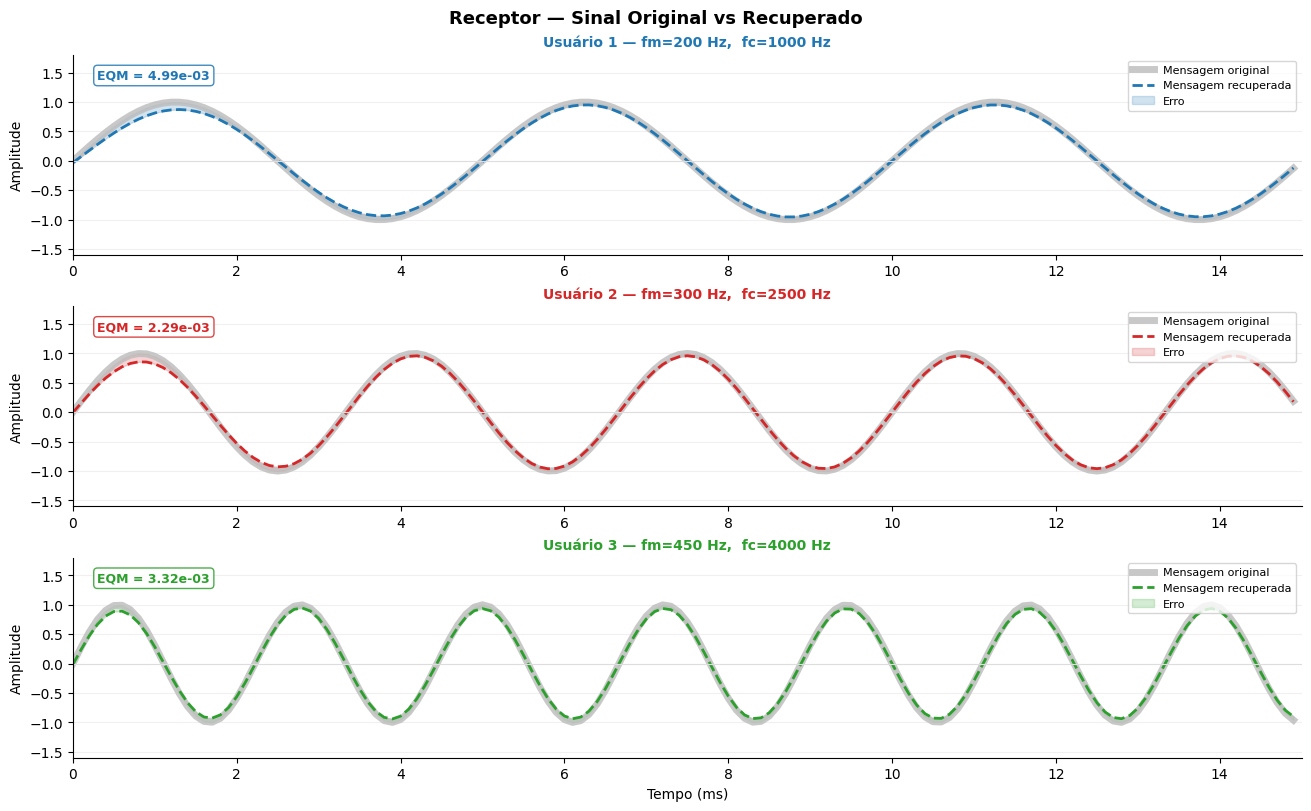

Qualidade da recuperação:
  Usuário 1: EQM = 4.99e-03  ✅ boa
  Usuário 2: EQM = 2.29e-03  ✅ boa
  Usuário 3: EQM = 3.32e-03  ✅ boa


In [4]:
# ── Por que a versão anterior falhava? ───────────────────────
# Ao multiplicar por cos(wc*t), a identidade trigonométrica dá:
#
#   m(t)*cos(wc*t) * cos(wc*t)
#   = m(t) * [0.5 + 0.5*cos(2*wc*t)]
#   = 0.5*m(t)          <- mensagem em banda base  MANTER
#   + 0.5*m(t)*cos(2wc) <- cópia em 2*fc           REMOVER com PBX
#
# O PBX deve ter corte = 1.5*fm  (acima da mensagem, bem abaixo de 2*fc)
# ─────────────────────────────────────────────────────────────

recuperados = {}
for nome, p in usuarios.items():
    fc, fm = p['fc'], p['fm']

    s1 = pbf(fdm, fc, bw=3*fm, ordem=4)            # isola o canal
    s2 = s1 * senoide(fc)                           # desloca para banda base
    s3 = 2.0 * pbx(s2, corte=1.5*fm, ordem=6)      # remove cópia em 2*fc
    recuperados[nome] = s3

janela = t <= 0.015

fig, eixos = plt.subplots(3, 1, figsize=(13, 8), constrained_layout=True)
fig.suptitle('Receptor — Sinal Original vs Recuperado',
             fontsize=13, fontweight='bold')

for ax, (nome, p) in zip(eixos, usuarios.items()):
    c    = p['cor']
    orig = mensagens[nome]
    rec  = recuperados[nome]
    eqm  = np.mean((orig - rec)**2)

    ax.plot(t[janela]*1000, orig[janela], color='#bbb', lw=5,
            alpha=0.8, label='Mensagem original')
    ax.plot(t[janela]*1000, rec[janela],  color=c, lw=2, ls='--',
            label='Mensagem recuperada')
    ax.fill_between(t[janela]*1000, orig[janela], rec[janela],
                    alpha=0.20, color=c, label='Erro')
    ax.axhline(0, color='#ddd', lw=0.8)
    ax.set_xlim(0, 15); ax.set_ylim(-1.6, 1.8)
    ax.legend(fontsize=8, loc='upper right')
    ax.text(0.02, 0.88, f'EQM = {eqm:.2e}', transform=ax.transAxes,
            fontsize=9, color=c, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=c, alpha=0.85))
    ax.set_title(f"{nome} — fm={p['fm']} Hz,  fc={p['fc']} Hz",
                 color=c, fontweight='bold', fontsize=10)
    ax.set_ylabel('Amplitude')
    estilo(ax)

eixos[-1].set_xlabel('Tempo (ms)')
plt.savefig('fdm_receptor.png', dpi=130, bbox_inches='tight')
plt.show()

print('Qualidade da recuperação:')
for nome, p in usuarios.items():
    eqm = np.mean((mensagens[nome] - recuperados[nome])**2)
    ok  = '✅ boa' if eqm < 0.01 else '⚠️  verificar filtros'
    print(f'  {nome}: EQM = {eqm:.2e}  {ok}')


## 🎛️ Célula 7 — Explorador Interativo de Filtros

Altere as variáveis no topo da célula e re-execute para ver o efeito:

| Parâmetro | O que controla | Efeito de aumentar |
|-----------|----------------|--------------------|
| `FATOR_BW_PBF` | Largura do PBF = fator × fm | Faixa mais larga → passa mais sinal, mas também mais interferência |
| `ORDEM_PBF` | Inclinação das bordas do PBF | Maior → corte mais abrupto, mais oscilação (*ringing*) |
| `FATOR_CORTE_PBX` | Corte do PBX = fator × fm | Maior → passa mais harmônicos, menos limpo |
| `ORDEM_PBX` | Inclinação das bordas do PBX | Maior → corte mais abrupto, mais oscilação |

**Experimentos para observar falhas típicas:**

```python
# ✅ Recuperação perfeita
FATOR_BW_PBF=3.0, ORDEM_PBF=4, FATOR_CORTE_PBX=1.5, ORDEM_PBX=6

# ❌ Corte do PBX muito baixo — elimina a mensagem
FATOR_BW_PBF=3.0, ORDEM_PBF=4, FATOR_CORTE_PBX=0.5, ORDEM_PBX=6

# ❌ Corte do PBX muito alto — harmônica 2*fc vaza
FATOR_BW_PBF=3.0, ORDEM_PBF=4, FATOR_CORTE_PBX=8.0, ORDEM_PBX=6

# ❌ PBF muito estreito — corta as bandas laterais
FATOR_BW_PBF=0.8, ORDEM_PBF=4, FATOR_CORTE_PBX=1.5, ORDEM_PBX=6

# ❌ PBF muito largo — canal vizinho vaza (crosstalk)
FATOR_BW_PBF=8.0, ORDEM_PBF=4, FATOR_CORTE_PBX=1.5, ORDEM_PBX=6

# ⚠️  Ordem baixa — rejeição fraca, filtros quase não funcionam
FATOR_BW_PBF=3.0, ORDEM_PBF=1, FATOR_CORTE_PBX=1.5, ORDEM_PBX=1
```


/tmp/ipykernel_1138/1647671157.py:112: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('fdm_explorador.png', dpi=130, bbox_inches='tight')
/tmp/ipykernel_1138/1647671157.py:112: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('fdm_explorador.png', dpi=130, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


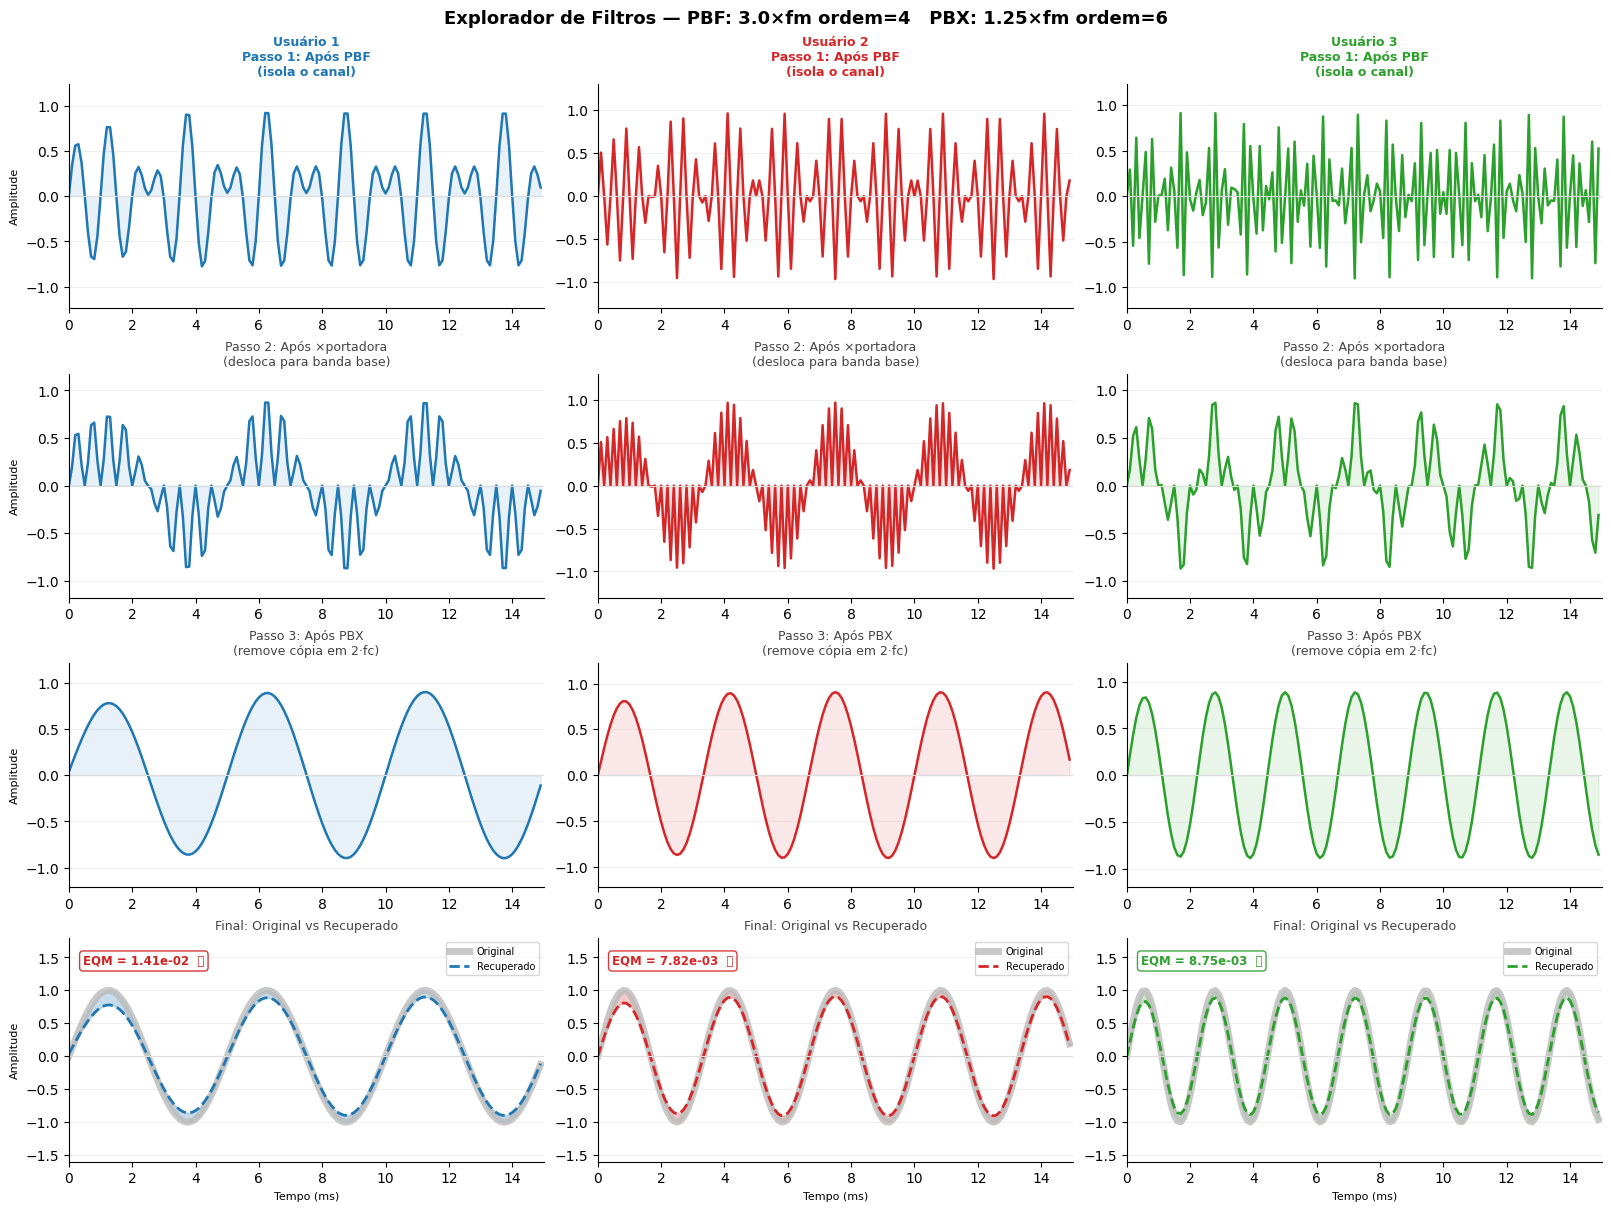

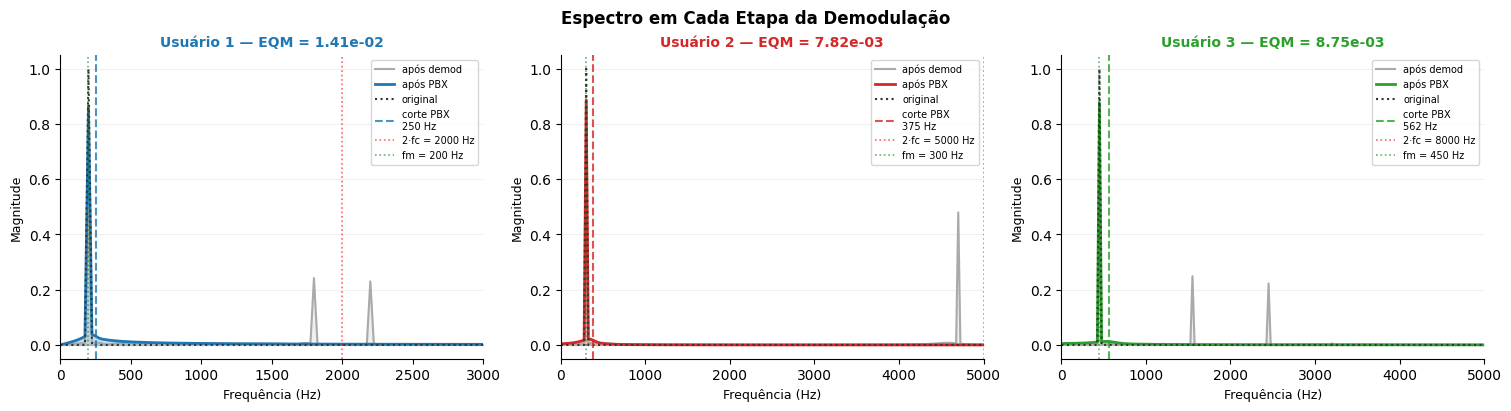

Configuração: PBF 3.0×fm ordem=4 | PBX 1.25×fm ordem=6

  Usuário 1: ❌ ruim   EQM=1.411e-02  ██████████████
  Usuário 2: ✅ boa    EQM=7.821e-03  ███████
  Usuário 3: ✅ boa    EQM=8.749e-03  ████████


In [9]:
# ================================================================
# CÉLULA 7 — EXPLORADOR INTERATIVO DE FILTROS
# Altere estes quatro números e re-execute a célula
# ================================================================

FATOR_BW_PBF      = 3.0   # largura do PBF = fator × fm  (experimente 0.8, 3, 8)
ORDEM_PBF         = 4     # ordem do PBF  (experimente 1, 2, 4, 8, 12)
FATOR_CORTE_PBX   = 1.5   # corte do PBX = fator × fm  (experimente 0.5, 1.5, 8)
ORDEM_PBX         = 6     # ordem do PBX  (experimente 1, 2, 4, 8, 12)



#### TESTS

# ATOR_CORTE_PBX = 0.5     # ❌ Mensagem desaparece     — corte abaixo de fm, elimina o sinal
# ATOR_CORTE_PBX = 8.0     # ❌ Recuperação ruidosa     — corte acima de 2·fc, harmônica vaza
# FATOR_BW_PBF = 0.8       # ❌ Sinal distorcido        — PBF muito estreito, corta as bandas laterais
# FATOR_BW_PBF = 8.0       # ❌ Diafonia (crosstalk)    — PBF muito largo, canal vizinho vaza
# ORDEM_PBF= 1             # ⚠️  Rejeição fraca     — rolloff suave, filtros quase não funcionam

FATOR_CORTE_PBX = 1.25     # ❌ Mensagem desaparece     — corte abaixo de fm, elimina o sinal
# ATOR_CORTE_PBX = 8.0     # ❌ Recuperação ruidosa     — corte acima de 2·fc, harmônica vaza
# FATOR_BW_PBF = 0.8       # ❌ Sinal distorcido        — PBF muito estreito, corta as bandas laterais
# FATOR_BW_PBF = 8.0       # ❌ Diafonia (crosstalk)    — PBF muito largo, canal vizinho vaza
# ORDEM_PBF= 1             # ⚠️  Rejeição fraca     — rolloff suave, filtros quase não funcionam


# ── Demodulação com os parâmetros atuais ─────────────────────
resultados = {}
for nome, p in usuarios.items():
    fc, fm = p['fc'], p['fm']
    bw_pbf   = FATOR_BW_PBF    * fm
    corte_px = FATOR_CORTE_PBX * fm
    s1 = pbf(fdm, fc, bw=bw_pbf,    ordem=ORDEM_PBF)
    s2 = s1 * senoide(fc)
    s3 = 2.0 * pbx(s2, corte=corte_px, ordem=ORDEM_PBX)
    eqm = np.mean((mensagens[nome] - s3) ** 2)
    resultados[nome] = dict(rec=s3, eqm=eqm,
                             bw_pbf=bw_pbf, corte_px=corte_px)

# ── Figura 1: grade 4 linhas × 3 colunas ─────────────────────
janela = t <= 0.015
fig, eixos = plt.subplots(4, 3, figsize=(16, 12), constrained_layout=True)
fig.suptitle(
    f'Explorador de Filtros — PBF: {FATOR_BW_PBF}×fm ordem={ORDEM_PBF}   '
    f'PBX: {FATOR_CORTE_PBX}×fm ordem={ORDEM_PBX}',
    fontsize=13, fontweight='bold')

titulos_linha = [
    'Passo 1: Após PBF\n(isola o canal)',
    'Passo 2: Após ×portadora\n(desloca para banda base)',
    'Passo 3: Após PBX\n(remove cópia em 2·fc)',
    'Final: Original vs Recuperado',
]

for col, (nome, p) in enumerate(usuarios.items()):
    fc, fm = p['fc'], p['fm']
    c   = p['cor']
    res = resultados[nome]

    # Recalcula os intermediários para o plot
    s1 = pbf(fdm, fc, bw=res['bw_pbf'],   ordem=ORDEM_PBF)
    s2 = s1 * senoide(fc)
    s3 = 2.0 * pbx(s2, corte=res['corte_px'], ordem=ORDEM_PBX)
    etapas = [s1, s2, s3]

    # Linhas 0-2: sinais intermediários
    for linha, sig in enumerate(etapas):
        ax   = eixos[linha, col]
        ymax = max(np.abs(sig[janela]).max() * 1.35, 0.5)
        ax.plot(t[janela]*1000, sig[janela], color=c, lw=1.8)
        ax.fill_between(t[janela]*1000, sig[janela], alpha=0.10, color=c)
        ax.axhline(0, color='#ddd', lw=0.8)
        ax.set_xlim(0, 15); ax.set_ylim(-ymax, ymax)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.yaxis.grid(True, color='#f0f0f0'); ax.set_axisbelow(True)
        titulo = f'{nome}\n{titulos_linha[linha]}' if linha == 0 else titulos_linha[linha]
        ax.set_title(titulo,
                     color=c if linha==0 else '#444',
                     fontweight='bold' if linha==0 else 'normal', fontsize=9)
        if col == 0: ax.set_ylabel('Amplitude', fontsize=8)

    # Linha 3: original vs recuperado
    ax   = eixos[3, col]
    orig = mensagens[nome]
    rec  = res['rec']
    eqm  = res['eqm']
    cor_badge = c if eqm < 0.01 else '#cc2222'

    ax.plot(t[janela]*1000, orig[janela], color='#bbb', lw=5,
            alpha=0.8, label='Original')
    ax.plot(t[janela]*1000, rec[janela],  color=c, lw=2, ls='--',
            label='Recuperado')
    ax.fill_between(t[janela]*1000, orig[janela], rec[janela],
                    alpha=0.25, color=c)
    ax.axhline(0, color='#ddd', lw=0.8)
    ax.set_xlim(0, 15); ax.set_ylim(-1.6, 1.8)
    ax.legend(fontsize=7, loc='upper right')
    rotulo = f'EQM = {eqm:.2e}  {"✅" if eqm < 0.01 else "❌"}'
    ax.text(0.03, 0.88, rotulo, transform=ax.transAxes,
            fontsize=8.5, fontweight='bold', color=cor_badge,
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec=cor_badge, alpha=0.9))
    ax.set_title(titulos_linha[3], fontsize=9, color='#444')
    ax.set_xlabel('Tempo (ms)', fontsize=8)
    if col == 0: ax.set_ylabel('Amplitude', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, color='#f0f0f0'); ax.set_axisbelow(True)

plt.savefig('fdm_explorador.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Figura 2: espectros antes e depois do PBX ────────────────
fig2, eixos2 = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fig2.suptitle('Espectro em Cada Etapa da Demodulação',
              fontsize=12, fontweight='bold')

for ax, (nome, p) in zip(eixos2, usuarios.items()):
    fc, fm = p['fc'], p['fm']
    c   = p['cor']
    res = resultados[nome]

    s1 = pbf(fdm, fc, bw=res['bw_pbf'],      ordem=ORDEM_PBF)
    s2 = s1 * senoide(fc)
    s3 = 2.0 * pbx(s2, corte=res['corte_px'], ordem=ORDEM_PBX)

    frq2, m2 = espectro(s2)             # após demodulação (antes do PBX)
    frq3, m3 = espectro(s3)             # após PBX
    frqo, mo = espectro(mensagens[nome])  # original

    ax.fill_between(frq2, m2, alpha=0.12, color='#888')
    ax.plot(frq2, m2, color='#aaa', lw=1.5, label='após demod')
    ax.fill_between(frq3, m3, alpha=0.25, color=c)
    ax.plot(frq3, m3, color=c,     lw=2.0, label='após PBX')
    ax.plot(frqo, mo, color='#333', lw=1.5, ls=':', label='original')

    ax.axvline(res['corte_px'], color=c,    lw=1.5, ls='--', alpha=0.8,
               label=f"corte PBX\n{res['corte_px']:.0f} Hz")
    ax.axvline(2*fc,            color='red', lw=1.2, ls=':', alpha=0.6,
               label=f'2·fc = {2*fc} Hz')
    ax.axvline(fm,              color='green', lw=1.2, ls=':', alpha=0.6,
               label=f'fm = {fm} Hz')

    xlim = min(2*fc * 1.5, FS/2)
    ax.set_xlim(0, xlim)
    ax.set_xlabel('Frequência (Hz)', fontsize=9)
    ax.set_ylabel('Magnitude',       fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_title(f'{nome} — EQM = {res["eqm"]:.2e}',
                 color=c, fontweight='bold', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, color='#f0f0f0'); ax.set_axisbelow(True)

plt.savefig('fdm_espectros_filtros.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Resumo ────────────────────────────────────────────────────
print(f'Configuração: PBF {FATOR_BW_PBF}×fm ordem={ORDEM_PBF} | '
      f'PBX {FATOR_CORTE_PBX}×fm ordem={ORDEM_PBX}')
print()
for nome, res in resultados.items():
    eqm = res['eqm']
    bar = '█' * int(min(eqm / 0.001, 30))
    ok  = '✅ boa  ' if eqm < 0.01 else '❌ ruim '
    print(f'  {nome}: {ok}  EQM={eqm:.3e}  {bar}')
